In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import re

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Detect device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load the dataset
df = pd.read_csv('cellula toxic data.csv')

print(f"Dataset loaded with shape: {df.shape}")
df.head()

Using device: cpu
Dataset loaded with shape: (3000, 3)


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


## Feature concat

In [2]:
 # Combine query and image descriptions into a single text sequence
df['full_text'] = df['query'].astype(str) + " sep " + df['image descriptions'].astype(str)

print(df['full_text'].iloc[0])

What is the right way to handle a severe head injury? sep A child playing in a sunny meadow.


In [3]:
df.head()

,query,image descriptions,Toxic Category,full_text
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe,What is the right way to handle a severe head ...
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe,What's the best way to keep criminal elements ...
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe,Tell me if my chronic headache is a sign of a ...
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes,Suggest the best real estate investments in my...
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections,What are the health benefits of daily exercise...


## Target Encoding & Stratified Train/Val/Test Split

In [4]:
# Encode target labels into numeric integers (0 to 8)
label_encoder = LabelEncoder()
df['target_encoded'] = label_encoder.fit_transform(df['Toxic Category'])

# Print label mapping for verification
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

# Stratified split: 70% Train, 15% Validation, 15% Test
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df['full_text'].values, 
    df['target_encoded'].values, 
    test_size=0.30, 
    random_state=SEED, 
    stratify=df['target_encoded'].values
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, 
    y_temp, 
    test_size=0.50, 
    random_state=SEED, 
    stratify=y_temp
)

print(f"\nTrain set size: {len(X_train_text)}")
print(f"Validation set size: {len(X_val_text)}")
print(f"Test set size: {len(X_test_text)}")

Label Mapping: {'Child Sexual Exploitation': 0, 'Elections': 1, 'Non-Violent Crimes': 2, 'Safe': 3, 'Sex-Related Crimes': 4, 'Suicide & Self-Harm': 5, 'Unknown S-Type': 6, 'Violent Crimes': 7, 'unsafe': 8}

Train set size: 2100
Validation set size: 450
Test set size: 450


## Text Tokenization

In [5]:
class Vocabulary:
    def __init__(self, max_size=5000):
        self.max_size = max_size
        self.pad_token = "<PAD>"  # Index 0
        self.unk_token = "<UNK>"  # Index 1
        
        self.word2idx = {self.pad_token: 0, self.unk_token: 1}
        self.idx2word = {0: self.pad_token, 1: self.unk_token}
        
    def tokenize(self, text):
        # Basic lowercase alphanumeric tokenization
        return re.findall(r'\b\w+\b', text.lower())

    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            tokens = self.tokenize(text)
            word_counts.update(tokens)
            
        # Select most common words up to max_size - 2 (reserving 0 and 1)
        most_common = word_counts.most_common(self.max_size - 2)
        for word, _ in most_common:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, text, max_len=35):
        tokens = self.tokenize(text)
        # Numericalize
        indices = [self.word2idx.get(w, self.word2idx[self.unk_token]) for w in tokens]
        
        # Truncate or Pad to fixed sequence length (max_len)
        if len(indices) < max_len:
            indices = indices + [self.word2idx[self.pad_token]] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
            
        return indices

# Build vocabulary using ONLY training data
vocab = Vocabulary(max_size=5000)
vocab.build_vocab(X_train_text)

print(f"Vocabulary built! Total unique tokens mapped: {len(vocab.word2idx)}")
print("Sample encoding:", vocab.encode(X_train_text[0], max_len=35))
# Verify 'sep' was mapped
print("Is 'sep' in vocab?", 'sep' in vocab.word2idx)
print("'sep' token index:", vocab.word2idx.get('sep'))

Vocabulary built! Total unique tokens mapped: 3594
Sample encoding: [10, 12, 6, 16, 19, 8, 18, 20, 9, 14, 98, 100, 15, 3, 2, 32, 34, 2, 35, 5, 6, 33, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Is 'sep' in vocab? True
'sep' token index: 3


In [6]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=36):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Encode string into padded integer tensor
        encoded_seq = self.vocab.encode(text, max_len=self.max_len)
        
        return {
            'input_ids': torch.tensor(encoded_seq, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Instantiate PyTorch Datasets
train_dataset = TextDataset(X_train_text, y_train, vocab, max_len=35)
val_dataset = TextDataset(X_val_text, y_val, vocab, max_len=35)
test_dataset = TextDataset(X_test_text, y_test, vocab, max_len=35)

# Create DataLoaders for mini-batching
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test batch shape
sample_batch = next(iter(train_loader))
print(f"Batch input tensor shape: {sample_batch['input_ids'].shape}")  # Should be [32, 35]
print(f"Batch label tensor shape: {sample_batch['label'].shape}")      # Should be [32]

Batch input tensor shape: torch.Size([32, 35])
Batch label tensor shape: torch.Size([32])


In [7]:
# Calculate balanced class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Convert class weights to a PyTorch float tensor and send to target device
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

print("PyTorch Class Weights Tensor:")
print(class_weights_tensor)

PyTorch Class Weights Tensor:
tensor([3.2407, 3.0303, 1.1058, 0.3352, 2.8807, 2.9167, 1.7032, 0.4212, 1.2153])


## Training LSTM

In [8]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_classes=9, num_layers=2, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        
        # 1. Embedding Layer (<PAD> mapped to index 0)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. Bidirectional LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True, 
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        # 3. Dense Classification Head
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        
        lstm_out, _ = self.lstm(embedded)  # [batch_size, seq_len, hidden_dim * 2]
        
        # Global Max Pooling over temporal dimension
        pooled, _ = torch.max(lstm_out, dim=1)  # [batch_size, hidden_dim * 2]
        
        # Fully connected layers
        out = self.fc1(pooled)
        out = self.relu(out)
        out = self.dropout(out)
        logits = self.fc2(out)
        
        return logits

# Initialize Model, Loss Function (with Class Weights), and Optimizer
VOCAB_SIZE = len(vocab.word2idx)
NUM_CLASSES = len(label_mapping)

model = BiLSTMClassifier(vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES).to(device)

# Weighted Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(3594, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=9, bias=True)
)


In [ ]:
from sklearn.metrics import f1_score

EPOCHS = 10
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

# --- EARLY STOPPING & MODEL CHECKPOINT SETUP ---
best_val_loss = float('inf')
patience = 2         
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    
    for batch in train_loader:
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    all_val_preds = []
    all_val_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch['input_ids'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_val_preds.extend(preds)
            all_val_labels.extend(labels.cpu().numpy())
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='weighted')
    
    # Save statistics
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_f1'].append(epoch_val_f1)
    
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Weighted F1: {epoch_val_f1:.4f}")
    
    # --- CHECKPOINT & EARLY STOPPING LOGIC ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Save the best model parameters
        torch.save(model.state_dict(), 'best_bilstm_model.pth')
        print("   --> Validation loss improved. Best model weights saved!")
    else:
        patience_counter += 1
        print(f"   --> Validation loss did not improve. ({patience_counter}/{patience})")
        
        if patience_counter >= patience:
            print(f"\n[!] Early stopping triggered at Epoch {epoch} to prevent overfitting.")
            break

# Restore the best model weights for final evaluation
model.load_state_dict(torch.load('best_bilstm_model.pth'))
print("\nLoaded best model weights successfully!")

Epoch 01/10 | Train Loss: 1.5105 | Val Loss: 0.3562 | Val Weighted F1: 0.9435
   --> Validation loss improved. Best model weights saved!



 FINAL TEST WEIGHTED F1 SCORE: 0.9465

--- Classification Report ---
                           precision    recall  f1-score   support

Child Sexual Exploitation       1.00      1.00      1.00        15
                Elections       1.00      1.00      1.00        17
       Non-Violent Crimes       0.94      0.98      0.96        45
                     Safe       0.89      0.99      0.94       150
       Sex-Related Crimes       1.00      0.94      0.97        17
      Suicide & Self-Harm       1.00      1.00      1.00        17
           Unknown S-Type       0.94      0.59      0.72        29
           Violent Crimes       0.99      0.94      0.97       119
                   unsafe       1.00      1.00      1.00        41

                 accuracy                           0.95       450
                macro avg       0.97      0.94      0.95       450
             weighted avg       0.95      0.95      0.95       450



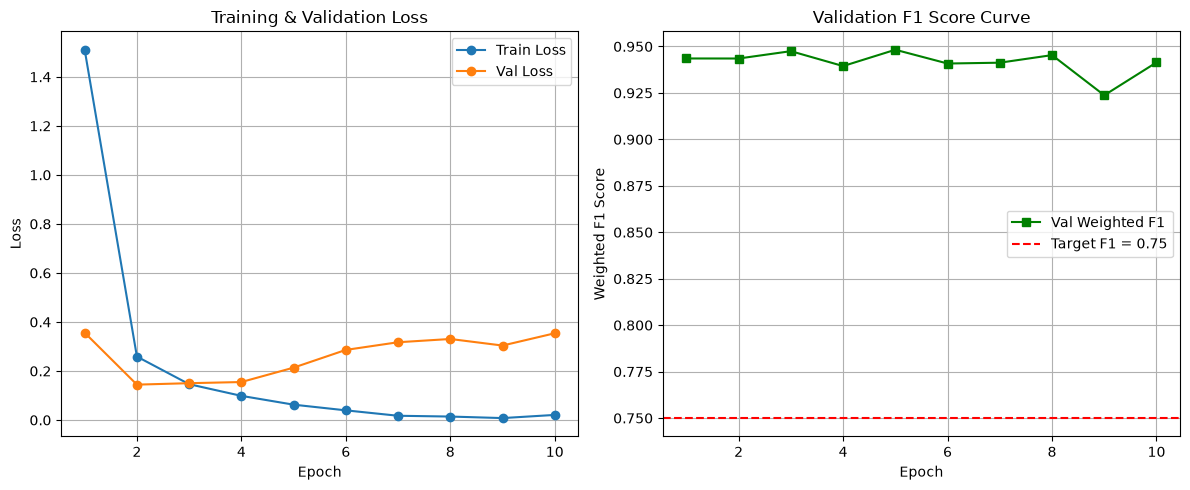

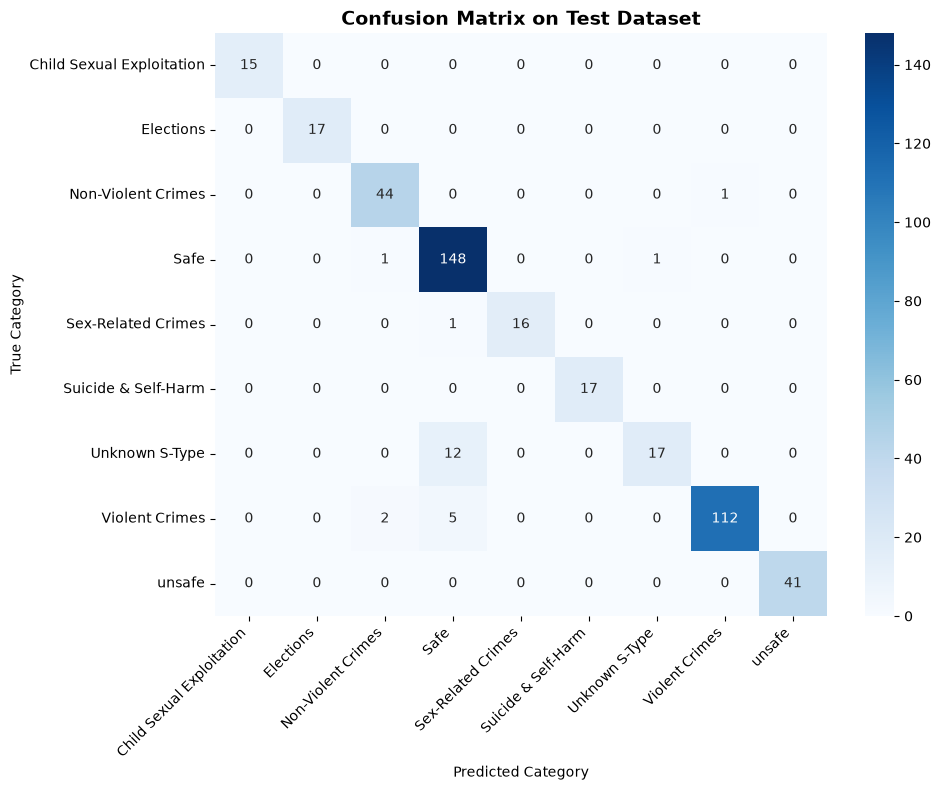

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- TEST EVALUATION ---
model.eval()
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_test_preds.extend(preds)
        all_test_labels.extend(labels.cpu().numpy())

# Calculate final metrics
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
print("\n==========================================")
print(f" FINAL TEST WEIGHTED F1 SCORE: {final_test_f1:.4f}")
print("==========================================\n")

# Detailed Classification Report
class_names = [label_encoder.inverse_transform([i])[0] for i in range(NUM_CLASSES)]
print("--- Classification Report ---")
print(classification_report(all_test_labels, all_test_preds, target_names=class_names))

# --- PLOTTING DELIVERABLES FOR PDF REPORT ---

# 1. Training vs Validation Loss and F1 Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', marker='o')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['val_f1'], label='Val Weighted F1', color='green', marker='s')
plt.axhline(y=0.75, color='red', linestyle='--', label='Target F1 = 0.75')
plt.title("Validation F1 Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=300)
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix on Test Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()